# Setup

In [ ]:
!pip install transformers torch Pillow pandas tqdm matplotlib

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageFile
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from transformers import CLIPProcessor, CLIPModel
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Menggunakan device: {device}")

Menggunakan device: cuda


In [ ]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
model_name = "laion/CLIP-ViT-L-14-DataComp.XL-s13B-b90K"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

# EDA

In [ ]:
import os

# 1. Tentukan path dataset Anda
dataset_path = "/content/drive/MyDrive/UBS Image Retrieval/dataset"

# 2. Tentukan ekstensi file yang dianggap sebagai gambar
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

print(f"{'NAMA FOLDER':<15} | {'JUMLAH GAMBAR'}")
print("-" * 35)

total_seluruh_dataset = 0
folder_count = 0

# 3. Cek apakah path dataset ada
if os.path.exists(dataset_path):
    # Dapatkan list semua folder dan urutkan secara alfabet
    folders = sorted([f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))])

    # Loop setiap folder
    for folder_name in folders:
        folder_full_path = os.path.join(dataset_path, folder_name)

        # Hitung file gambar di dalam folder tersebut
        files = [f for f in os.listdir(folder_full_path) if f.lower().endswith(valid_extensions)]
        count = len(files)

        # Tampilkan hasil per folder
        print(f"{folder_name:<15} | {count}")

        total_seluruh_dataset += count
        folder_count += 1

    print("-" * 35)
    print(f"{'TOTAL JENIS':<15} | {folder_count}")
    print(f"{'TOTAL GAMBAR':<15} | {total_seluruh_dataset}")

else:
    print(f"Error: Path tidak ditemukan -> {dataset_path}")
    print("Pastikan Google Drive sudah di-mount.")

NAMA FOLDER     | JUMLAH GAMBAR
-----------------------------------
Error: Path tidak ditemukan -> /content/drive/MyDrive/UBS Image Retrieval/dataset
Pastikan Google Drive sudah di-mount.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Fine tuning

In [ ]:
model_name = "laion/CLIP-ViT-L-14-DataComp.XL-s13B-b90K"

LR = 1e-6
EPOCHS = 5
BATCH_SIZE = 4

DATASET_DIR = "/content/drive/MyDrive/UBS Image Retrieval/dataset_v31_validated"
SAVE_DIR = "/content/drive/MyDrive/UBS Image Retrieval/clip_jewelery_finetuned_final"

print(f"⚙️ Memulai Fine-Tuning...")

def create_dataset_metadata(root_dir):
    data = []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')

    for category in os.listdir(root_dir):
        cat_path = os.path.join(root_dir, category)
        if not os.path.isdir(cat_path): continue

        for product_name in os.listdir(cat_path):
            prod_path = os.path.join(cat_path, product_name)
            if not os.path.isdir(prod_path): continue

            for img_file in os.listdir(prod_path):
                if img_file.lower().endswith(valid_extensions):
                    img_path = os.path.join(prod_path, img_file)
                    clean_prod_name = product_name.replace("_", " ")
                    caption = f"{category} {clean_prod_name}"

                    if "_AR" in img_file: caption += " front view"
                    elif "_BR" in img_file: caption += " side view"
                    elif "_CR" in img_file: caption += " detail view"

                    data.append({'image_path': img_path, 'caption': caption})
    df = pd.DataFrame(data)
    print(f"✅ Ditemukan {len(df)} pasangan gambar-teks.")
    return df

class JewelryFolderDataset(Dataset):
    def __init__(self, dataframe, processor):
        self.df = dataframe
        self.processor = processor

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(row['image_path']).convert("RGB")
            inputs = self.processor(text=[row['caption']], images=image, return_tensors="pt", padding="max_length", truncation=True, max_length=77)
            return {k: v.squeeze(0) for k, v in inputs.items()}
        except:
            return self.__getitem__((idx + 1) % len(self.df))

def fine_tune_clip_folder():
    df = create_dataset_metadata(DATASET_DIR)
    if len(df) == 0: return

    print(f"🚀 Memuat model dasar: {model_name} ...")
    model = CLIPModel.from_pretrained(model_name).to(device)
    processor = CLIPProcessor.from_pretrained(model_name)

    dataset = JewelryFolderDataset(df, processor)
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    scaler = GradScaler()

    model.train()
    for epoch in range(EPOCHS):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        epoch_loss = 0

        for batch in pbar:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            pixel_values = batch['pixel_values'].to(device)

            with autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values, return_loss=True)
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        print(f"✅ Epoch {epoch+1} Selesai. Avg Loss: {epoch_loss / len(train_loader):.4f}")

    print("💾 Menyimpan model Fine-Tuned...")
    os.makedirs(SAVE_DIR, exist_ok=True)
    model.save_pretrained(SAVE_DIR)
    processor.save_pretrained(SAVE_DIR)
    print(f"🎉 Model tersimpan di: {SAVE_DIR}")

# HAPUS TANDA PAGAR DI BAWAH JIKA INGIN TRAINING ULANG:
fine_tune_clip_folder()

⚙️ Sistem Siap. Device: cuda
📂 Mengambil data dari: /content/drive/MyDrive/UBS Image Retrieval/dataset_v31_validated
🔍 Scanning folder dataset...
✅ Ditemukan 1559 pasangan gambar-teks.
🚀 Memuat model: laion/CLIP-ViT-L-14-DataComp.XL-s13B-b90K ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: e7a7983d-9add-4cee-988b-ec4e9c7cd5c1)')' thrown while requesting HEAD https://huggingface.co/laion/CLIP-ViT-L-14-DataComp.XL-s13B-b90K/resolve/main/config.json
Retrying in 1s [Retry 1/5].


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

✅ Epoch 3 Selesai. Avg Loss: 0.0801


Epoch 4/5: 100%|██████████| 390/390 [02:39<00:00,  2.44it/s, loss=0.0071]


✅ Epoch 4 Selesai. Avg Loss: 0.0556


Epoch 5/5: 100%|██████████| 390/390 [02:44<00:00,  2.38it/s, loss=0.0001]


✅ Epoch 5 Selesai. Avg Loss: 0.0631
💾 Menyimpan model ke Google Drive...
🎉 SELESAI! Model tersimpan di: /content/drive/MyDrive/UBS Image Retrieval/clip_jewelery_finetuned_final


# Indexing

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/UBS Image Retrieval/clip_jewelery_finetuned_final"
DATASET_PATH = "/content/drive/MyDrive/UBS Image Retrieval/dataset_v31_validated"
OUTPUT_DB_PATH = "/content/drive/MyDrive/UBS Image Retrieval/clip_database.pth"
BATCH_SIZE = 32

print("\n[1/3] Memuat Model Fine-Tuned...")
model = CLIPModel.from_pretrained(MODEL_PATH).to(device)
processor = CLIPProcessor.from_pretrained(MODEL_PATH)
model.eval()

class ImageListDatasetIdx(Dataset):
    def __init__(self, root_dir, processor):
        self.image_paths = []
        self.processor = processor
        valid_exts = {'.jpg', '.jpeg', '.png', '.webp'}
        for root, dirs, files in os.walk(root_dir):
            if ".ipynb_checkpoints" in root: continue # Abaikan folder hantu
            for file in files:
                if os.path.splitext(file)[1].lower() in valid_exts:
                    self.image_paths.append(os.path.join(root, file))

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.image_paths[idx]).convert("RGB")
            inputs = self.processor(images=img, return_tensors="pt", padding=True)
            return inputs['pixel_values'].squeeze(0), self.image_paths[idx]
        except: return torch.zeros((3, 224, 224)), "CORRUPT"

print("[2/3] Mengekstrak Fitur...")
dataset_idx = ImageListDatasetIdx(DATASET_PATH, processor)
loader_idx = DataLoader(dataset_idx, batch_size=BATCH_SIZE, num_workers=2, shuffle=False)

all_features, all_paths = [], []
with torch.no_grad():
    for imgs, paths in tqdm(loader_idx, desc="Processing"):
        valid_mask = [p != "CORRUPT" for p in paths]
        if not any(valid_mask): continue
        imgs = imgs[valid_mask].to(device)
        current_paths = [p for p, v in zip(paths, valid_mask) if v]

        features = model.get_image_features(pixel_values=imgs)
        features = features / features.norm(dim=-1, keepdim=True)

        all_features.append(features.cpu())
        all_paths.extend(current_paths)

final_features = torch.cat(all_features)

print(f"\n[3/3] Menyimpan Database...")
torch.save({'features': final_features, 'paths': all_paths}, OUTPUT_DB_PATH)
print(f"🎉 SUKSES! Database tersimpan di: {OUTPUT_DB_PATH}")

Incremental Indexing (Untuk tambah dataset baru)

---



In [ ]:
import os
import torch
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from transformers import CLIPProcessor, CLIPModel

# --- KONFIGURASI ---
MODEL_PATH = "/content/drive/MyDrive/UBS Image Retrieval/clip_jewelery_finetuned_final"
DATASET_PATH = "/content/drive/MyDrive/UBS Image Retrieval/dataset_v31_validated"
OUTPUT_DB_PATH = "/content/drive/MyDrive/UBS Image Retrieval/clip_database.pth"
BATCH_SIZE = 32

print("\n[1/4] Memuat Model Fine-Tuned...")
model = CLIPModel.from_pretrained(MODEL_PATH).to(device)
processor = CLIPProcessor.from_pretrained(MODEL_PATH)
model.eval()

# Dataset khusus untuk memproses list spesifik (bukan seluruh folder)
class SpecificImageDataset(Dataset):
    def __init__(self, image_paths, processor):
        self.image_paths = image_paths
        self.processor = processor

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            img = Image.open(img_path).convert("RGB")
            inputs = self.processor(images=img, return_tensors="pt", padding=True)
            return inputs['pixel_values'].squeeze(0), img_path
        except: return torch.zeros((3, 224, 224)), "CORRUPT"

def update_database():
    print("\n[2/4] Memeriksa Database Lama & Folder Dataset...")

    # A. Scan semua file yang ada di folder fisik (Kenyataan saat ini)
    valid_exts = {'.jpg', '.jpeg', '.png', '.webp'}
    current_files = []
    for root, dirs, files in os.walk(DATASET_PATH):
        if ".ipynb_checkpoints" in root: continue # Hindari folder hantu
        for file in files:
            if os.path.splitext(file)[1].lower() in valid_exts:
                current_files.append(os.path.join(root, file))

    current_files_set = set(current_files)
    print(f"   -> Ditemukan {len(current_files_set)} gambar di folder lokal.")

    # B. Load Database Lama (Ingatan masa lalu)
    existing_paths = []
    existing_features = None

    if os.path.exists(OUTPUT_DB_PATH):
        try:
            checkpoint = torch.load(OUTPUT_DB_PATH, map_location='cpu')
            existing_paths = checkpoint['paths']
            existing_features = checkpoint['features']
            print(f"   -> Database lama ditemukan dengan {len(existing_paths)} item terindeks.")
        except Exception as e:
            print(f"   ⚠️ Gagal memuat database lama: {e}. Akan membuat dari awal.")

    existing_paths_set = set(existing_paths)

    # C. Bandingkan! (Matematika Himpunan)
    new_files = list(current_files_set - existing_paths_set) # Ada di folder, gak ada di DB
    deleted_files = existing_paths_set - current_files_set   # Ada di DB, gak ada di folder

    print(f"\n📊 RINGKASAN UPDATE:")
    print(f"   🟢 File Baru (Akan di-index)  : {len(new_files)}")
    print(f"   🔴 File Dihapus (Akan dibuang): {len(deleted_files)}")
    print(f"   ⚪ File Tetap (Akan di-skip)  : {len(existing_paths) - len(deleted_files)}")

    # D. Pelihara data lama yang masih valid (Filter yang dihapus)
    updated_paths = []
    updated_features_list = []

    if existing_features is not None and len(existing_paths) > 0:
        for i, p in enumerate(existing_paths):
            if p not in deleted_files:
                updated_paths.append(p)
                # Ambil tensor per gambar dan jadikan list (shape: 1, 768)
                updated_features_list.append(existing_features[i].unsqueeze(0))

    # E. Proses HANYA file baru
    new_features_list = []
    new_paths_valid = []

    if len(new_files) > 0:
        print(f"\n[3/4] Mengekstrak Fitur untuk {len(new_files)} File Baru...")
        dataset = SpecificImageDataset(new_files, processor)
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=False)

        with torch.no_grad():
            for imgs, paths in tqdm(loader, desc="Processing New"):
                valid_mask = [p != "CORRUPT" for p in paths]
                if not any(valid_mask): continue

                imgs = imgs[valid_mask].to(device)
                current_batch_paths = [p for p, v in zip(paths, valid_mask) if v]

                features = model.get_image_features(pixel_values=imgs)
                features = features / features.norm(dim=-1, keepdim=True)

                new_features_list.append(features.cpu())
                new_paths_valid.extend(current_batch_paths)
    else:
        print("\n[3/4] Tidak ada gambar baru. Melewati proses ekstraksi AI.")

    # F. Gabungkan Data (Lama yang valid + Baru)
    final_paths = updated_paths + new_paths_valid
    final_features_tensors = updated_features_list + new_features_list

    if len(final_features_tensors) == 0:
        print("❌ Database kosong. Tidak ada yang disimpan.")
        return

    # Satukan semua list of tensor menjadi 1 tensor besar
    final_features = torch.cat(final_features_tensors, dim=0)

    # G. Simpan / Timpa File Lama
    print(f"\n[4/4] Menyimpan Database Baru ke Google Drive...")
    torch.save({'features': final_features, 'paths': final_paths}, OUTPUT_DB_PATH)
    print(f"🎉 SUKSES! Database terbaru berhasil disimpan dengan total {len(final_paths)} item.")

# Eksekusi
update_database()

# Evaluation

In [ ]:
print(f"⚙️ Evaluasi Model")

# Gunakan memory variables dari Indexing jika ada, jika tidak load dari file
db_feats = final_features.to(device)
db_paths = np.array(all_paths)

def get_label(path):
    return os.path.basename(os.path.dirname(path))

def evaluate(features, paths, k_list=[1, 3, 5]):
    sim_matrix = (features @ features.T).cpu().numpy()
    labels = np.array([get_label(p) for p in paths])
    num_samples = len(labels)

    map_score = 0.0
    precision_scores = {k: 0.0 for k in k_list}
    recall_scores = {k: 0.0 for k in k_list}

    for i in tqdm(range(num_samples), desc="Scoring"):
        query_label = labels[i]
        scores = sim_matrix[i].copy()
        scores[i] = -np.inf # Abaikan diri sendiri

        sorted_indices = np.argsort(scores)[::-1]
        retrieved_labels = labels[sorted_indices]

        relevance_mask = (retrieved_labels == query_label)
        total_relevant = np.sum(labels == query_label) - 1

        if total_relevant > 0:
            relevant_ranks = np.where(relevance_mask)[0] + 1
            ap = np.sum(np.arange(1, len(relevant_ranks) + 1) / relevant_ranks) / total_relevant
            map_score += ap

            for k in k_list:
                num_correct = np.sum(relevance_mask[:k])
                precision_scores[k] += num_correct / k
                recall_scores[k] += num_correct / total_relevant

    return map_score / num_samples, {k: v / num_samples for k, v in precision_scores.items()}, {k: v / num_samples for k, v in recall_scores.items()}

target_k = [1, 3, 5]
mAP, prec, rec = evaluate(db_feats, db_paths, k_list=target_k)

print("\n" + "="*45)
print(f"📊 HASIL EVALUASI")
print("="*45)
print(f"Total Sampel    : {len(db_paths)}")
print(f"mAP Score       : {mAP:.4f}")
print("-" * 45)
print(f"{'Metric':<10} | {'@1':<8} | {'@3':<8} | {'@5':<8}")
print("-" * 45)
print(f"{'Precision':<10} | {prec[1]:.4f}   | {prec[3]:.4f}   | {prec[5]:.4f}")
print(f"{'Recall':<10}    | {rec[1]:.4f}   | {rec[3]:.4f}   | {rec[5]:.4f}")
print("="*45)

⚙️ Evaluasi Model RAKSASA (ViT-L-14 DataComp)
📂 Model Path: /content/drive/MyDrive/UBS Image Retrieval/clip_jewelery_finetuned_final
📂 Dataset: /content/drive/MyDrive/UBS Image Retrieval/dataset_v31_validated
🎯 Target Metrics: Top-1, Top-3, Top-5

[1/4] Memuat Model...
✅ Model berhasil dimuat!

[2/4] Re-Indexing Database...


Extracting:   0%|          | 0/49 [00:00<?, ?it/s]


[3/4] Menghitung Skor Akurasi...


Scoring:   0%|          | 0/1558 [00:00<?, ?it/s]


📊 HASIL EVALUASI (Model ViT-L-14 DataComp)
Total Sampel    : 1558
mAP Score       : 0.6299
---------------------------------------------
Metric     | @1       | @3       | @5      
---------------------------------------------
Precision  | 0.6804   | 0.4101   | 0.2688
Recall        | 0.3444   | 0.6197   | 0.6765


# Visulization

🎲 Random Query: UBS Gold Kalung Emas Birthstone - KKV15026-4 - 17K - Dec_BR.jpg
❌ Database fitur tidak ditemukan di memori. Jalankan Evaluasi dulu!


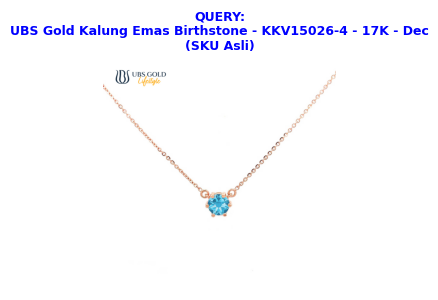

In [ ]:
import random

def search_jewelry(query_path, top_k=5):
    model.eval()
    with torch.no_grad():
        img = Image.open(query_path).convert("RGB")
        inputs = processor(images=img, return_tensors="pt", padding=True).to(device)
        q_feat = model.get_image_features(**inputs)
        q_feat = q_feat / q_feat.norm(dim=-1, keepdim=True)

        sim = (q_feat @ db_feats.T).squeeze(0)
        values, indices = sim.topk(top_k + 1)

    results = []
    for score, idx in zip(values, indices):
        path = db_paths[idx.item()]
        if path == query_path: continue
        results.append((path, score.item()))
    return results[:top_k]

# Pilih Random Query
rand_idx = random.randint(0, len(db_paths)-1)
query_file = db_paths[rand_idx]
query_lbl = get_label(query_file)

print(f"🎲 Random Query: {os.path.basename(query_file)}")
results = search_jewelry(query_file, top_k=5)

plt.figure(figsize=(15, 6))

# A. Tampilkan Query
ax = plt.subplot(1, 6, 1)
ax.imshow(Image.open(query_file).convert("RGB"))
ax.set_title(f"QUERY:\n{query_lbl}", color='blue', fontsize=9, fontweight='bold')
ax.axis('off')

# B. Tampilkan Hasil
for i, (path, score) in enumerate(results):
    ax = plt.subplot(1, 6, i + 2)
    ax.imshow(Image.open(path).convert("RGB"))

    res_lbl = get_label(path)
    is_correct = (res_lbl == query_lbl)

    color = 'green' if is_correct else 'red'
    status = "✅ BENAR" if is_correct else "⚠️ BEDA SKU"

    ax.set_title(f"Rank #{i+1} ({score:.2f})\n{status}\n{res_lbl}", color=color, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()